# Modelo de preço justo (todas as categorias)

Este notebook generaliza o `v2_01_modelo_preco_ram` para as **6 categorias** do
projeto (RAM, CPU, GPU, SSD, Fonte, Placa-mãe) num único loop. Para cada uma:

1. Filtra o `df` combinado por `categoria_key`.
2. Aplica limpeza, filtro de sanidade e split treino/calibração/teste.
3. Treina `modelo_media` (RandomForest) + `modelo_variancia` (nos resíduos²).
4. Calibra a faixa por *conformal normalizado* com corte de largura 90%.
5. Salva `.joblib` com pré-processador, modelos, `q_norm` e métricas.

Depois do loop, uma seção de **análise por categoria** (SHAP, detector de
oferta, comparação com TabICL) roda para *uma* categoria por vez — escolha via
`CATEGORIA_ANALISE` na célula correspondente.

> Cobertura alvo de 90% → `alpha = 0.10`.

In [1]:
!pip install shap

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import pathlib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

import shap

RANDOM_STATE = 42
alpha = 0.10 # cobertura alvo de 90%
CATEGORIA = "ram"  # (cpu, gpu, ...)


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\julia\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


C:\Users\julia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset

Em vez de um único snapshot, juntamos o `kabum_todas_pecas_<data>.csv` de **cada**
pasta de coleta em `00_Dados` num único DataFrame (várias datas, todas as
categorias). Isso dá mais linhas de treino, ao custo de ainda não termos as specs
extraídas via NLP (`ram_geracao`, `ram_gb`, `ram_mhz`, `ram_cl`) para as coletas
mais recentes — só a pasta `2026-05-16` tem os `_features.csv`. Por enquanto
seguimos só com o que está disponível em todas as coletas; a extração de specs
fica para um passo posterior.

In [15]:
import os
import pathlib
 
# 00_Dados/ mora na raiz do repositorio (um nivel acima deste notebook).
# Defina a variavel de ambiente KABUM_DATA_ROOT para apontar para outro lugar
# sem editar o codigo.
DATA_ROOT = os.environ.get("KABUM_DATA_ROOT", str(pathlib.Path("..", "00_Dados")))
MODEL_DIR = "../modelos"
 
FEATURES_COLS = {
    "ram":       ["ram_geracao", "ram_gb", "ram_mhz", "ram_cl", "ram_notebook"],
    "cpu":       ["cpu_marca", "cpu_socket", "cpu_serie", "cpu_tdp_w",
                  "cpu_ddr_suportado", "cpu_com_cooler"],
    "gpu":       ["gpu_marca_chip", "gpu_modelo", "gpu_vram_gb", "gpu_tdp_w"],
    "ssd":       ["ssd_interface", "ssd_geracao_pcie", "ssd_capacidade_gb", "ssd_notebook"],
    "fonte":     ["fonte_wattagem", "fonte_certificacao", "fonte_modular", "fonte_atx3"],
    "placa_mae": ["mobo_socket", "mobo_chipset", "mobo_ddr", "mobo_form_factor",
                  "mobo_slots_m2", "mobo_max_ram_gb"],
}
 
 
def carregar_pasta(pasta: pathlib.Path):
    """Lê uma pasta de coleta usando todas_pecas + merge OU _features.csv direto."""
    data_coleta = pasta.name
    arq_todas = pasta / f"kabum_todas_pecas_{data_coleta}.csv"
 
    if arq_todas.exists():
        base = pd.read_csv(arq_todas)
        # fluxo original: merge com _features.csv por id
        for cat, cols in FEATURES_COLS.items():
            arq_feat = pasta / f"kabum_{cat}_{data_coleta}_features.csv"
            if not arq_feat.exists():
                continue
            feat = pd.read_csv(arq_feat, usecols=lambda c: c == "id" or c in cols)
            if "id" not in feat.columns:
                continue
            base = base.merge(feat, on="id", how="left")
        return base, "via todas_pecas + merge"
 
    # fluxo alternativo: concatena os _features.csv (já autocontidos)
    dfs = []
    for cat in FEATURES_COLS:
        arq_feat = pasta / f"kabum_{cat}_{data_coleta}_features.csv"
        if arq_feat.exists():
            dfs.append(pd.read_csv(arq_feat, encoding="utf-8-sig"))
    if not dfs:
        return None, None
    return pd.concat(dfs, ignore_index=True, sort=False), "via _features.csv"
 
 
root = pathlib.Path(DATA_ROOT)
pastas = sorted(p for p in root.iterdir() if p.is_dir())
assert pastas, f"Nenhuma pasta de coleta em {DATA_ROOT}"
 
print(f"{len(pastas)} pasta(s) encontradas:")
dfs_datas = []
for pasta in pastas:
    base, fonte_txt = carregar_pasta(pasta)
    if base is None:
        print(f"  [pulei] {pasta.name}: nenhum CSV lido")
        continue
    print(f" - {pasta.name}: {len(base):>5} linhas ({fonte_txt})")
    dfs_datas.append(base)
 
df = pd.concat(dfs_datas, ignore_index=True, sort=False)
print(f"\nshape combinado: {df.shape}")

6 pasta(s) encontradas:
 - 2026-06-26:  4577 linhas (via _features.csv)
 - 2026-06-28:  4569 linhas (via _features.csv)
 - 2026-06-30:  4575 linhas (via _features.csv)
 - 2026-07-01:  4573 linhas (via _features.csv)
 - 2026-07-02:  4561 linhas (via _features.csv)
 - 2026-07-06:  4779 linhas (via todas_pecas + merge)

shape combinado: (27634, 45)


In [11]:
df.head()

,data_coleta,categoria_key,id,nome,preco_original,preco_atual,preco_pix,desconto_pct,avaliacao,num_avaliacoes,...,fonte_wattagem,fonte_certificacao,fonte_modular,fonte_atx3,mobo_socket,mobo_chipset,mobo_ddr,mobo_form_factor,mobo_slots_m2,mobo_max_ram_gb
0,2026-06-26,ram,172366,"Memória RAM Kingston Fury Beast, 16GB, 3200MHz...",1319.66,1319.66,1121.71,15,5,1225,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-06-26,ram,922165,"Memória RAM Husky Impulse, 8GB, 3200MHz, DDR4,...",647.05,647.05,549.99,15,5,259,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-06-26,ram,922166,"Memória RAM Husky Impulse, 16GB, 3200MHz, DDR4...",1176.46,1176.46,999.99,15,5,85,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-06-26,ram,383892,"Memória RAM Rise Mode Z, 8GB, 3200MHz, DDR4, C...",0.00,447.05,379.99,15,5,691,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-06-26,ram,526516,"Memória RAM XPG Lancer, RGB, 32GB (2x16GB), 60...",4235.28,4235.28,3599.99,15,5,279,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Conferindo a junção

Antes de seguir: quantas datas entraram, quantos produtos por categoria, e se há
duplicatas (mesmo `id` repetido **dentro da mesma data** seria um sinal de
problema; o mesmo produto aparecendo em datas diferentes é esperado).

In [6]:
print("datas de coleta:", sorted(df["data_coleta"].unique()))
print()
print(df["categoria_key"].value_counts())
print()
dups_mesma_data = df.duplicated(subset=["id", "data_coleta"]).sum()
print("duplicatas (mesmo id na mesma data):", dups_mesma_data)
print()
print("valores ausentes por coluna:")
print(df.isna().sum())

datas de coleta: ['2026-06-26', '2026-06-28', '2026-06-30', '2026-07-01', '2026-07-02', '2026-07-06']

categoria_key
ram          7326
placa_mae    5301
ssd          5230
fonte        3595
cpu          3264
gpu          2918
Name: count, dtype: int64

duplicatas (mesmo id na mesma data): 426

valores ausentes por coluna:
data_coleta               0
categoria_key             0
id                        0
nome                      0
preco_original            0
preco_atual               0
preco_pix                 0
desconto_pct              0
avaliacao                 0
num_avaliacoes            0
disponivel                0
fabricante                0
categoria                 0
garantia                  0
frete_gratis              0
url                       0
ram_geracao           20908
ram_gb                20349
ram_mhz               22380
ram_cl                25749
ram_notebook          20308
cpu_socket            24986
cpu_tdp_w             27325
cpu_com_cooler        24370
cpu_m

## Configuração das features e loop de treino

`FEATURES` mapeia, por categoria, quais colunas são numéricas e categóricas.
`SANIDADE` guarda limites físicos conhecidos (ex.: DDR não passa de 9000 MHz
hoje) — valores fora viram `NaN` e são tratados pela imputação da mediana.

Se você identificar outros outliers de extração em outras categorias
(análogos ao `56600 MHz` que resolvemos para RAM), adicione a regra ao
dicionário `SANIDADE` e re-rode.

In [16]:
# ============================================================
# CÉLULA 9 (loop de treino) — versão SEM log-transform
# ============================================================
#
# Rollback: modelo volta a prever preço em R$ diretamente.
# Mantém as melhorias que sobreviveram:
#   - filtro NAO_GENUINOS_NOME (GPU profissional)
#   - sanidade estendida (ram_gb, gpu_vram_gb)
#   - warning do regex corrigido (`(?:...)` em vez de `(...)`)

ALVO = "preco_pix"
PRECO_MIN, PRECO_MAX = 1, None
MODEL_DIR = "../modelos"

CATEGORIAS = ["ram", "cpu", "gpu", "ssd", "fonte", "placa_mae"]

FEATURES = {
    "ram":       {"num": ["ram_gb", "ram_mhz", "ram_cl"],
                  "cat": ["ram_geracao", "fabricante"]},
    "cpu":       {"num": ["cpu_tdp_w", "cpu_cores", "cpu_threads", "cpu_clock_ghz"],
                  "cat": ["cpu_socket", "cpu_marca", "cpu_ddr_suportado",
                          "cpu_serie", "fabricante"]},
    "gpu":       {"num": ["gpu_vram_gb", "gpu_tdp_w"],
                  "cat": ["fabricante", "gpu_marca_chip", "gpu_modelo"]},
    "ssd":       {"num": ["ssd_capacidade_gb", "ssd_leitura_mbs"],
                  "cat": ["ssd_interface", "ssd_geracao_pcie", "fabricante"]},
    "fonte":     {"num": ["fonte_wattagem"],
                  "cat": ["fonte_modular", "fonte_certificacao", "fabricante"]},
    "placa_mae": {"num": ["mobo_slots_m2"],
                  "cat": ["mobo_socket", "mobo_ddr", "mobo_form_factor",
                          "mobo_chipset", "fabricante"]},
}

SANIDADE = {
    "ram_mhz":         (0, 9000),
    "ram_gb":          (1, 256),
    "gpu_vram_gb":     (1, 48),
    # SSDs de consumidor vão de 32GB até 8TB (8192GB); acima é ruído
    # (geralmente número de série capturado pelo regex).
    "ssd_capacidade_gb": (32, 8192),
}

# padrões de nome que indicam produto NÃO-alvo da categoria
# (adaptadores/coolers/cases, e produtos profissionais/enterprise
# que enviesam o modelo de consumo).
# Usamos (?:...) para não capturar grupos (evita UserWarning do pandas).
NAO_GENUINOS_NOME = {
    "gpu": r"\b(?:quadro|tesla|rtx\s?a\d{4}|rtx\s?ada|h100|h200|a100|a800|"
           r"a40|a30|a10\b|l40|l4\b|mi\d{3}|instinct)\b",
    "ssd": r"\b(?:case|gaveta|adaptador|dock|"
           r"dc600m|dc1500|dc500|"           # SSDs enterprise Kingston
           r"pm[0-9]{3,}|pm893|"             # Samsung enterprise
           r"micron\s?\d{4}|"                # Micron enterprise séries
           r"sas\b|"                          # SSDs SAS (só servidor)
           r"para\s+servidor|para servidor|"
           r"poweredge|proliant|r\d{3}\s|r\d{4}\s"   # nomes de servidor Dell/HP
           r")\b",
}


def quantil_conformal(scores, alpha):
    n = len(scores)
    nivel = np.ceil((n + 1) * (1 - alpha)) / n
    return np.quantile(scores, nivel, method="higher")


import os
import sys
os.makedirs(MODEL_DIR, exist_ok=True)

# features.py mora em ../02_features (raiz do repo tem 4 pastas por etapa
# do pipeline: 01_coleta, 02_features, 03_modelagem, 04_app).
sys.path.insert(0, str(pathlib.Path("..", "02_features").resolve()))

# Reaplica extração de todas as categorias que ganharam features novas.
# O df veio dos _features.csv das coletas antigas, gerados antes dessas
# melhorias em features.py, então re-extraímos aqui.
try:
    from features import (
        features_gpu, features_cpu, features_ssd, features_placa_mae,
        normalizar_gpu_modelo,
    )

    REPROC = {
        "gpu":       (features_gpu,       ["gpu_marca_chip", "gpu_modelo", "gpu_vram_gb", "gpu_tdp_w"]),
        "cpu":       (features_cpu,       ["cpu_socket", "cpu_marca", "cpu_serie",
                                            "cpu_tdp_w", "cpu_ddr_suportado", "cpu_com_cooler",
                                            "cpu_cores", "cpu_threads", "cpu_clock_ghz"]),
        "ssd":       (features_ssd,       ["ssd_interface", "ssd_geracao_pcie",
                                            "ssd_capacidade_gb", "ssd_leitura_mbs", "ssd_notebook"]),
        "placa_mae": (features_placa_mae, ["mobo_socket", "mobo_chipset", "mobo_ddr",
                                            "mobo_form_factor", "mobo_slots_m2", "mobo_max_ram_gb"]),
    }

    for cat, (fn, cols) in REPROC.items():
        mask = df["categoria_key"] == cat
        if not mask.any():
            continue
        sub = fn(df.loc[mask, ["nome"]].copy())
        for c in cols:
            if c in sub.columns:
                # cria coluna no df se não existir (features novas)
                if c not in df.columns:
                    df[c] = None
                df.loc[mask, c] = sub[c].values
        if cat == "gpu":
            df.loc[mask, "gpu_modelo"] = df.loc[mask, "gpu_modelo"].apply(normalizar_gpu_modelo)
        # relatório de cobertura das features principais
        feat_referencia = {
            "gpu": "gpu_modelo", "cpu": "cpu_cores",
            "ssd": "ssd_leitura_mbs", "placa_mae": "mobo_chipset",
        }[cat]
        cov = df.loc[mask, feat_referencia].notna().sum()
        print(f"[re-extração {cat}] {feat_referencia}: "
              f"{cov}/{mask.sum()} ({cov/mask.sum()*100:.0f}%)")
except Exception as exc:
    print(f"[re-extração] pulado: {exc}")

resultados = []
resultados_por_cat = {}

for CATEGORIA in CATEGORIAS:
    print(f"\n{'='*60}\n{CATEGORIA.upper()}\n{'='*60}")

    cfg = FEATURES[CATEGORIA]
    num = [c for c in cfg["num"] if c in df.columns]
    cat = [c for c in cfg["cat"] if c in df.columns]
    faltando = set(cfg["num"] + cfg["cat"]) - set(num + cat)
    if faltando:
        print("  AVISO: colunas configuradas ausentes no CSV, serão ignoradas:", faltando)
    if not num and not cat:
        print("  [pulei] nenhuma feature disponível para esta categoria")
        continue

    # ---- limpeza + sanidade ----
    d = df[df["categoria_key"] == CATEGORIA].copy()
    d = d.dropna(subset=[ALVO])
    d = d[d[ALVO] >= PRECO_MIN]
    if PRECO_MAX is not None:
        d = d[d[ALVO] <= PRECO_MAX]
    d = d.drop_duplicates(subset=["nome"]) if "nome" in d.columns else d

    # remove produtos que não são a peça-alvo da categoria (ex.: GPU profissional)
    if CATEGORIA in NAO_GENUINOS_NOME:
        padrao = NAO_GENUINOS_NOME[CATEGORIA]
        fora = d["nome"].str.contains(padrao, case=False, na=False, regex=True)
        if fora.any():
            print(f"  [não-genuíno] {fora.sum()} produtos removidos (padrão {CATEGORIA})")
            d = d[~fora]

    for col, (lo, hi) in SANIDADE.items():
        if col in d.columns:
            fora = ~d[col].between(lo, hi) & d[col].notna()
            if fora.any():
                print(f"  [sanidade] {fora.sum()} valor(es) de {col} fora de [{lo},{hi}] -> NaN")
                d.loc[fora, col] = np.nan

    if len(d) < 30:
        print(f"  [pulei] só {len(d)} produtos após limpeza — poucos dados pra treinar")
        continue

    X = d[num + cat].copy()

    # normalização de tipos das categóricas
    for c in cat:
        X[c] = X[c].where(X[c].isna(), X[c].astype(str))

    y = d[ALVO].to_numpy()
    print(f"  {len(d)} produtos após limpeza  |  num={num}  cat={cat}")

    # ---- split 60/20/20 ----
    X_treino_cal, X_teste, y_treino_cal, y_teste = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE
    )
    X_treino, X_cal, y_treino, y_cal = train_test_split(
        X_treino_cal, y_treino_cal, test_size=0.25, random_state=RANDOM_STATE
    )

    # ---- pré-processamento ----
    preproc = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), num),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="constant", fill_value="desconhecido")),
            ("oh",  OneHotEncoder(handle_unknown="ignore", min_frequency=10,
                                  sparse_output=False)),
        ]), cat),
    ])

    Xtr_arr = preproc.fit_transform(X_treino)
    feat_nomes = preproc.get_feature_names_out()
    Xtr = pd.DataFrame(Xtr_arr, columns=feat_nomes, index=X_treino.index)
    Xca = pd.DataFrame(preproc.transform(X_cal),   columns=feat_nomes, index=X_cal.index)
    Xte = pd.DataFrame(preproc.transform(X_teste), columns=feat_nomes, index=X_teste.index)

    # ---- modelos (SEM log) ----
    modelo_media = RandomForestRegressor(
        n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE
    )
    modelo_media.fit(Xtr, y_treino)

    residuos = y_treino - modelo_media.predict(Xtr)
    modelo_variancia = RandomForestRegressor(
        n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE
    )
    modelo_variancia.fit(Xtr, residuos ** 2)

    pred_teste = modelo_media.predict(Xte)
    mae = mean_absolute_error(y_teste, pred_teste)
    r2 = r2_score(y_teste, pred_teste)
    print(f"  MAE teste: R$ {mae:.2f}  |  R² teste: {r2:.3f}")

    # ---- conformal normalizado ----
    escala_cal = np.sqrt(np.maximum(modelo_variancia.predict(Xca), 1e-6))
    scores_norm = np.abs(y_cal - modelo_media.predict(Xca)) / escala_cal
    q_norm = quantil_conformal(scores_norm, alpha)

    escala_teste = np.sqrt(np.maximum(modelo_variancia.predict(Xte), 1e-6))
    baixo_norm = pred_teste - q_norm * escala_teste
    baixo_norm = np.maximum(baixo_norm, 0)
    alto_norm  = pred_teste + q_norm * escala_teste

    cobertura = float(((y_teste >= baixo_norm) & (y_teste <= alto_norm)).mean())
    largura_media = float(np.mean(alto_norm - baixo_norm))
    print(f"  cobertura: {cobertura:.1%}  |  largura média: R$ {largura_media:.2f}")

    bundle = {
        "categoria": CATEGORIA,
        "alvo": ALVO,
        "alpha": alpha,
        "num": num,
        "cat": cat,
        "preproc": preproc,
        "modelo_media": modelo_media,
        "modelo_variancia": modelo_variancia,
        "q_norm": q_norm,
        "feature_nomes": list(feat_nomes),
        "usa_log": False,   # <<< explícito: modelo prevê preço em R$
        "metricas": {
            "mae": float(mae),
            "r2": float(r2),
            "cobertura": cobertura,
            "largura_media": largura_media,
        },
    }
    caminho = f"{MODEL_DIR}/modelo_preco_{CATEGORIA}.joblib"
    joblib.dump(bundle, caminho)

    res_teste_df = d.loc[X_teste.index, ["nome", ALVO]].copy() if "nome" in d.columns else pd.DataFrame({ALVO: y_teste}, index=X_teste.index)
    res_teste_df["preco_previsto"] = pred_teste
    res_teste_df["faixa_baixo"] = baixo_norm
    res_teste_df["faixa_alto"] = alto_norm
    res_teste_df.to_csv(f"{MODEL_DIR}/resultado_teste_{CATEGORIA}.csv", index=False)

    resultados_por_cat[CATEGORIA] = {
        "bundle": bundle, "d": d,
        "X_treino": X_treino, "X_cal": X_cal, "X_teste": X_teste,
        "y_treino": y_treino, "y_cal": y_cal, "y_teste": y_teste,
        "Xtr": Xtr, "Xca": Xca, "Xte": Xte,
        "pred_teste": pred_teste,
        "baixo_norm": baixo_norm, "alto_norm": alto_norm,
        "q_norm": q_norm, "modelo_media": modelo_media, "modelo_variancia": modelo_variancia,
        "preproc": preproc, "feat_nomes": feat_nomes,
        "num": num, "cat": cat,
    }

    resultados.append({"categoria": CATEGORIA, "n_produtos": len(d), **bundle["metricas"]})

print("\n" + "="*60 + "\nResumo final\n" + "="*60)
resumo_final = pd.DataFrame(resultados)
resumo_final.to_csv(f"{MODEL_DIR}/resumo_metricas.csv", index=False)
resumo_final

[re-extração gpu] gpu_modelo: 2455/2918 (84%)
[re-extração] pulado: 'cpu_cores'

RAM
  [sanidade] 2 valor(es) de ram_mhz fora de [0,9000] -> NaN
  1274 produtos após limpeza  |  num=['ram_gb', 'ram_mhz', 'ram_cl']  cat=['ram_geracao', 'fabricante']
  MAE teste: R$ 269.45  |  R² teste: 0.865
  cobertura: 86.3%  |  largura média: R$ 956.19

CPU
  AVISO: colunas configuradas ausentes no CSV, serão ignoradas: {'cpu_cores', 'cpu_threads', 'cpu_clock_ghz'}
  559 produtos após limpeza  |  num=['cpu_tdp_w']  cat=['cpu_socket', 'cpu_marca', 'cpu_ddr_suportado', 'cpu_serie', 'fabricante']
  MAE teste: R$ 529.34  |  R² teste: 0.620
  cobertura: 96.4%  |  largura média: R$ 3383.56

GPU
  [não-genuíno] 15 produtos removidos (padrão gpu)
  [sanidade] 1 valor(es) de gpu_vram_gb fora de [1,48] -> NaN
  518 produtos após limpeza  |  num=['gpu_vram_gb', 'gpu_tdp_w']  cat=['fabricante', 'gpu_marca_chip', 'gpu_modelo']
  MAE teste: R$ 1721.84  |  R² teste: 0.592
  cobertura: 88.5%  |  largura média: R$ 53

,categoria,n_produtos,mae,r2,cobertura,largura_media
0,ram,1274,269.450088,0.864998,0.862745,956.193179
1,cpu,559,529.343581,0.619782,0.964286,3383.556200
2,gpu,518,1721.838947,0.591867,0.884615,5350.227405
3,ssd,879,682.750559,0.372907,0.926136,2282.186500
4,fonte,627,142.579491,0.692018,0.920635,802.707083
5,placa_mae,935,598.725805,0.378974,0.887701,2222.979813


---

## Análise detalhada por categoria

As células abaixo (visualização da faixa, detector de oferta, SHAP, TabICL,
função de inferência) foram desenhadas para rodar **uma categoria de cada
vez**. Escolha em `CATEGORIA_ANALISE` qual bundle carregar do dicionário
`resultados_por_cat` gerado pelo loop, e re-rode as células daqui pra frente.

Para trocar de categoria depois: mude só `CATEGORIA_ANALISE` e re-rode a
próxima célula (a que popula as variáveis `pred_teste`, `Xte`, etc.).

In [6]:
CATEGORIA_ANALISE = "ram"     # troque para "cpu", "gpu", "ssd", "fonte" ou "placa_mae"

r = resultados_por_cat[CATEGORIA_ANALISE]

# desempacota para as variáveis que as células seguintes esperam
bundle          = r["bundle"]
d               = r["d"]
X_treino, X_cal, X_teste = r["X_treino"], r["X_cal"], r["X_teste"]
y_treino, y_cal, y_teste = r["y_treino"], r["y_cal"], r["y_teste"]
Xtr, Xca, Xte   = r["Xtr"], r["Xca"], r["Xte"]
pred_teste      = r["pred_teste"]
baixo_norm      = r["baixo_norm"]
alto_norm       = r["alto_norm"]
q_norm          = r["q_norm"]
modelo_media    = r["modelo_media"]
modelo_variancia= r["modelo_variancia"]
preproc         = r["preproc"]
feat_nomes      = r["feat_nomes"]
num, cat        = r["num"], r["cat"]
CATEGORIA       = CATEGORIA_ANALISE
print(f"Análise carregada: {CATEGORIA}  ({len(d)} produtos, {len(X_teste)} no teste)")
print("métricas:", bundle["metricas"])

Análise carregada: ram  (1435 produtos, 287 no teste)
métricas: {'mae': 251.9828836491681, 'r2': 0.9152587524226807, 'cobertura': 0.926829268292683, 'largura_media': 1223.866157989423}


### Visualizando as faixas

Ordenando os produtos de teste pelo preço previsto, a faixa (conformal
normalizado) fica larga onde o modelo está mais incerto, estreita onde está
mais seguro. Preço real caindo dentro da faixa = previsão consistente.

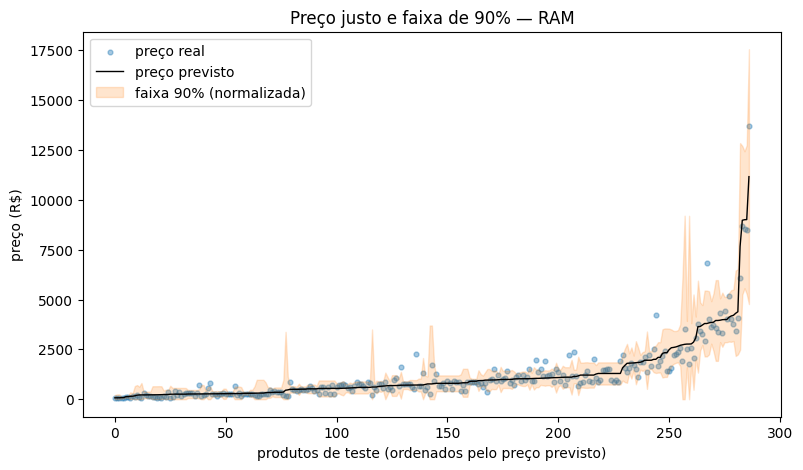

In [7]:
ordem = np.argsort(pred_teste)
xx = np.arange(len(pred_teste))

plt.figure(figsize=(9, 5))
plt.scatter(xx, y_teste[ordem], s=12, alpha=0.4, label="preço real")
plt.plot(xx, pred_teste[ordem], color="black", linewidth=1, label="preço previsto")
plt.fill_between(xx, baixo_norm[ordem], alto_norm[ordem], alpha=0.20,
                 color="tab:orange", label="faixa 90% (normalizada)")
plt.xlabel("produtos de teste (ordenados pelo preço previsto)")
plt.ylabel("preço (R$)")
plt.title(f"Preço justo e faixa de 90% — {CATEGORIA.upper()}")
plt.legend()
plt.show()

## Detector de oferta

A regra é direta: comparado com a faixa prevista, um produto cujo preço real está

- **abaixo** do piso da faixa → `oferta` (bom negócio),
- **acima** do teto → `caro`,
- **dentro** → `justo`.

`desvio_pct` mede o quanto o preço real está distante do preço justo previsto
(negativo = mais barato que o previsto). É esse número que vai virar o *ranking* do
recomendador no v2, no lugar do score à mão.

In [8]:
def classificar(preco_real, pred, lo, hi):
    if preco_real < lo:  status = "oferta"
    elif preco_real > hi: status = "caro"
    else:                 status = "justo"
    return status

res_teste = X_teste.copy()
if "nome" in d.columns:
    res_teste.insert(0, "nome", d.loc[X_teste.index, "nome"])
res_teste["preco_real"]  = y_teste
res_teste["preco_justo"] = pred_teste.round(2)
res_teste["faixa_baixo"] = baixo_norm.round(2)
res_teste["faixa_alto"]  = alto_norm.round(2)
res_teste["desvio_pct"]  = ((y_teste - pred_teste) / pred_teste * 100).round(1)
res_teste["status"] = [classificar(r, p, lo, hi)
                       for r, p, lo, hi in zip(y_teste, pred_teste, baixo_norm, alto_norm)]

print(res_teste["status"].value_counts())
# melhores ofertas (mais abaixo do preço justo)
cols = [c for c in ["nome", "preco_real", "preco_justo", "faixa_baixo", "faixa_alto", "desvio_pct", "status"] if c in res_teste.columns]
res_teste.sort_values("desvio_pct").head(10)[cols]

status
justo     266
caro       17
oferta      4
Name: count, dtype: int64


,nome,preco_real,preco_justo,faixa_baixo,faixa_alto,desvio_pct,status
4044,"Memória Notebook Nanya, 2GB, 1333MHz, DDR3 - P...",60.01,229.79,0.0,649.43,-73.9,justo
4666,"Memória RAM XLinne, 8GB, DDR3, 1600MHz, CL11",187.85,609.36,0.0,3498.70,-69.2,justo
8292,Memoria 4gb Ddr3 1333 Cl 11 1.5v Desktop Udim...,66.95,215.14,0.0,813.98,-68.9,justo
4668,Memória Ram Ddr3 8GB 1600mhz Cl11 1.5v 240pin ...,239.85,767.88,0.0,3697.05,-68.8,justo
3717,"Memória Bluecase SODIMM, 4GB, 1333MHz, DDR3, P...",82.49,250.21,0.0,676.48,-67.0,justo
4400,"Memória Golden Memory, 4gb, 1600mhz, Ddr3, Cl1...",149.90,451.45,0.0,3379.47,-66.8,justo
4688,"Memoria Ram Perfil Baixo Ddr3 8GB, 1600mhz, PC...",159.90,467.75,0.0,1134.31,-65.8,justo
4415,Memória Ram Ddr3 4gb 1600mhz PC3-12800u Smart,78.00,223.10,0.0,651.23,-65.0,justo
31805,Memoria Ddr4 16gb 2666mhz Keepdata,347.03,959.96,403.6,1516.33,-63.8,oferta
4189,"Memoria Ddr3l 1,35v Para Notebook 4gb 1600mhz ...",103.99,223.10,0.0,651.23,-53.4,justo


## SHAP — explicando o preço

Usamos o `TreeExplainer` (rápido para RandomForest). A propriedade central é a
**aditividade**: `previsão = base + Σ SHAP`. Explicamos o conjunto de teste.

In [9]:
explainer = shap.TreeExplainer(modelo_media)
shap_values = explainer(Xte)

i = 0
soma = shap_values.base_values[i] + shap_values.values[i].sum()
print(f"base + Σ SHAP = {soma:.2f}   |   modelo.predict = {pred_teste[i]:.2f}")

base + Σ SHAP = 283.98   |   modelo.predict = 283.98


**Importância global** — média dos `|SHAP|`: quais features mais mexem no preço
(magnitude, sem direção).

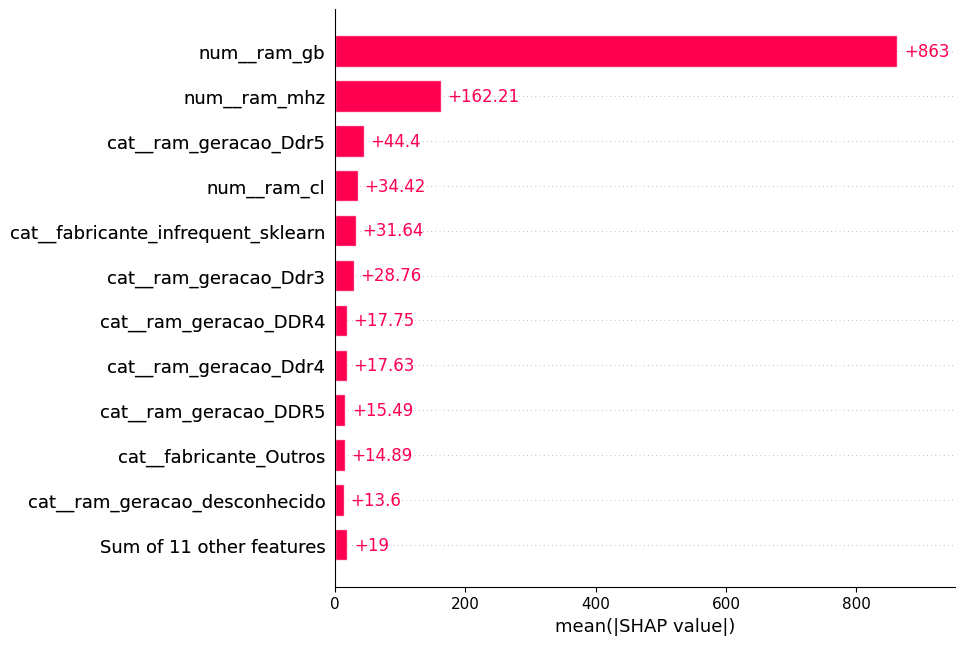

In [10]:
shap.plots.bar(shap_values, max_display=12)

**Beeswarm** — adiciona direção e distribuição. Cor = valor da feature
(vermelho alto, azul baixo); eixo X = empurrão no preço. Espere ver capacidade e
frequência altas puxando o preço pra cima.

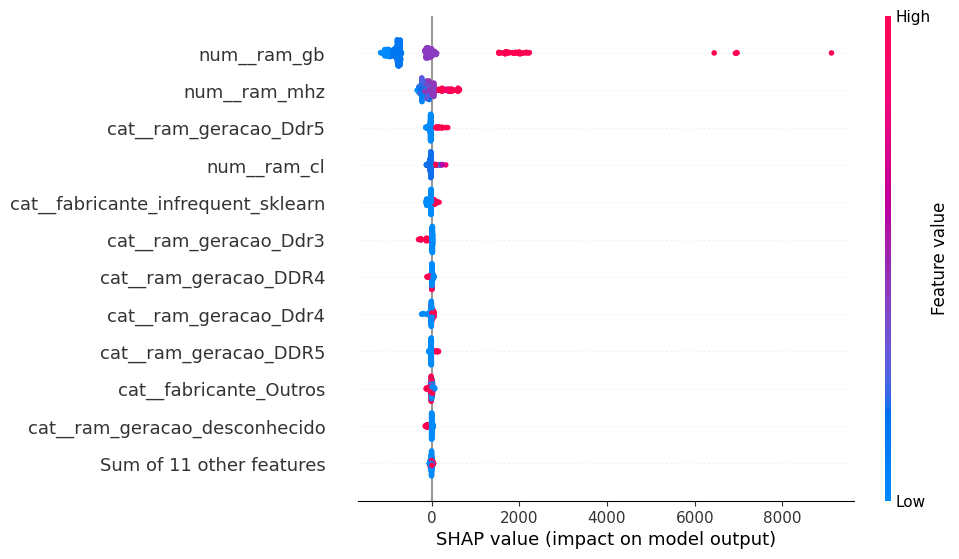

In [11]:
shap.plots.beeswarm(shap_values, max_display=12)

**Waterfall** — explica **um** produto: da média até o preço final, feature a
feature. Ótimo pro app mostrar *por que* aquele preço.

Memória RAM Kingston Fury Beast, 128GB (4x32GB), 5600MHz, DDR5, CL40,para Intel XMP, Preto - KF556C40BBK4-128
preço real: 13679.90 | previsto: 11163.22


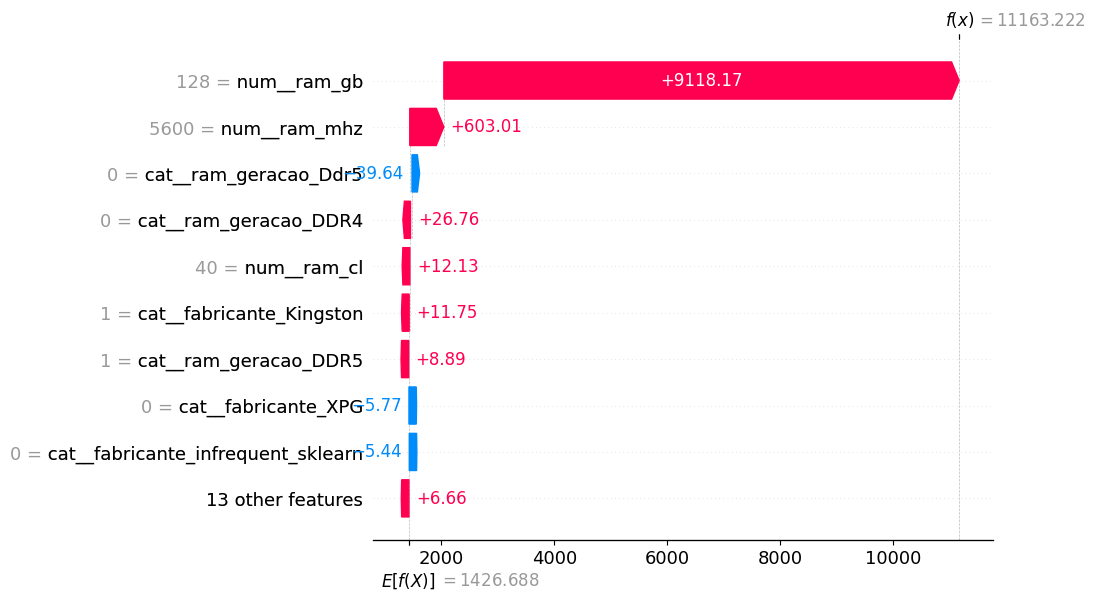

In [12]:
j = int(np.argmax(pred_teste))   # o mais caro previsto, por exemplo
if "nome" in d.columns:
    print(d.loc[X_teste.index[j], "nome"])
print(f"preço real: {y_teste[j]:.2f} | previsto: {pred_teste[j]:.2f}")
shap.plots.waterfall(shap_values[j])

**Scatter** — efeito de uma feature específica. Mostra se o
efeito é linear, tem limiar, ou depende de outras variáveis (dispersão vertical).

Por padrão, mostra a primeira feature numérica da categoria. Para escolher
outra, ajuste `feat_alvo` abaixo.

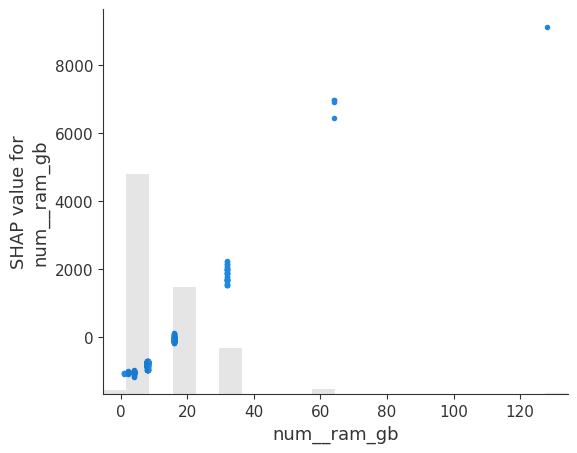

In [13]:
# escolhe a primeira feature numérica da categoria atual
if num:
    feat_alvo = f"num__{num[0]}"
    if feat_alvo in Xte.columns:
        shap.plots.scatter(shap_values[:, feat_alvo])
    else:
        print(f"coluna {feat_alvo} não encontrada em Xte — colunas disponíveis:")
        print(list(Xte.columns))
else:
    print("nenhuma feature numérica na categoria — pulei o scatter")

### Auxiliar: `resumo()` para comparar métodos de incerteza

Define a função que resume cobertura e largura média de qualquer par
`(baixo, alto)` — usada abaixo para comparar RF+conformal com TabICL.

In [14]:
def resumo(nome, lo, hi):
    return {
        "metodo": nome,
        "cobertura": ((y_teste >= lo) & (y_teste <= hi)).mean(),
        "largura_media": np.mean(hi - lo),
    }

# aplica ao próprio conformal normalizado, só para conferir
pd.DataFrame([resumo("RF + conformal norm.", baixo_norm, alto_norm)])

,metodo,cobertura,largura_media
0,RF + conformal norm.,0.926829,1223.866158


## Comparação com modelo fundacional (TabICL)

O TabICL prevê **sem tuning** e devolve **quantis** — uma faixa de 90% direto do
modelo (quantis 5% e 95%), sem calibração. Comparamos:

- **acurácia** (MAE) do TabICL out-of-the-box vs a RandomForest;
- **incerteza**: faixa nativa do TabICL vs RF + conformal normalizado.

A célula é opcional e protegida: se o `tabicl` não estiver instalado, ela apenas
avisa e segue. Para instalar: `pip install tabicl`.

> A célula abaixo é opcional e demorada (baixa checkpoint do Hugging Face).
> Só rode se estiver com internet e quiser comparar. Para pular, comente-a.

In [15]:
try:
    from tabicl import TabICLRegressor

    # TabICL recebe o contexto = treino + calibração (mesma info dos outros)
    X_ctx = np.vstack([Xtr.to_numpy(), Xca.to_numpy()])
    y_ctx = np.concatenate([y_treino, y_cal])

    reg = TabICLRegressor()
    reg.fit(X_ctx, y_ctx)

    saida = reg.predict(Xte.to_numpy(),
                        output_type=["mean", "quantiles"],
                        alphas=[0.05, 0.5, 0.95])
    pred_tabicl = saida["mean"]
    baixo_tab = saida["quantiles"][:, 0]
    alto_tab  = saida["quantiles"][:, 2]

    tab = pd.DataFrame([
        {"modelo": "RandomForest",           "MAE": mean_absolute_error(y_teste, pred_teste)},
        {"modelo": "TabICL (sem tuning)",     "MAE": mean_absolute_error(y_teste, pred_tabicl)},
    ])
    print(tab.to_string(index=False))

    inc = pd.DataFrame([
        resumo("RF + conformal norm.",   baixo_norm, alto_norm),
        resumo("TabICL quantis nativos", baixo_tab, alto_tab),
    ])
    display(inc)
except ModuleNotFoundError:
    print("tabicl não instalado — pulei esta comparação. (pip install tabicl)")

             modelo        MAE
       RandomForest 251.982884
TabICL (sem tuning) 220.343015


,metodo,cobertura,largura_media
0,RF + conformal norm.,0.926829,1223.866158
1,TabICL quantis nativos,0.930314,906.742126


### Função de inferência (a mesma que o app vai usar)

Recebe as specs de um produto (um dicionário), aplica o pré-processador salvo e
devolve preço justo + faixa. No app, um passo anterior extrai essas specs do nome
via as regexes do notebook de NLP.

> O exemplo abaixo é específico para RAM. Se `CATEGORIA_ANALISE` for
> outra, ajuste o dicionário de specs de entrada conforme as features da
> categoria (veja `bundle["num"] + bundle["cat"]`).

In [16]:
def prever_preco(specs: dict, bundle=bundle):
    X1 = pd.DataFrame([specs])
    for c in bundle["num"] + bundle["cat"]:
        if c not in X1.columns:
            X1[c] = np.nan
    X1 = X1[bundle["num"] + bundle["cat"]]
    Xt = pd.DataFrame(bundle["preproc"].transform(X1),
                      columns=bundle["preproc"].get_feature_names_out())
    p = float(bundle["modelo_media"].predict(Xt)[0])
    esc = float(np.sqrt(max(bundle["modelo_variancia"].predict(Xt)[0], 1e-6)))
    lo, hi = p - bundle["q_norm"] * esc, p + bundle["q_norm"] * esc
    return {"preco_justo": round(p, 2), "faixa": (round(lo, 2), round(hi, 2))}

# exemplo
prever_preco({"ram_gb": 16, "ram_mhz": 3200, "ram_cl": 16,
              "ram_geracao": "DDR4", "fabricante": "Kingston"})

{'preco_justo': 1262.09, 'faixa': (np.float64(812.57), np.float64(1711.61))}

## Próximos passos

Com os 6 `.joblib` gerados pelo loop e o `resumo_metricas.csv` no diretório
`modelos/`, os próximos passos do projeto são:

- **Recomendador v2**: trocar o score de custo-benefício à mão pelo
  `desvio_pct` (distância do preço real ao preço justo previsto) no ranking
  dos dois modos.
- **App (Streamlit)**: carregar os `.joblib`, oferecer as três telas — build
  por orçamento, peças compatíveis, e *analisar um produto* (cola nome +
  preço → veredito barato/justo/caro + waterfall SHAP).
- **Refinar `SANIDADE`**: à medida que rodar o notebook, cada categoria pode
  revelar outliers de extração (como o `56600 MHz` da RAM). Adicione-os ao
  dicionário `SANIDADE` para que a limpeza seja robusta em novas coletas.